# CKP02 — DocMind RAG

Demonstração executável do **Recruta AI**, continuação do chatbot de recrutamento e RH do CKP01. O notebook é deliberadamente fino: a lógica testável permanece em `app/`, enquanto as células validam a base entregue e apresentam as evidências reais preservadas das fases 2 a 5.

**Modelos aprovados:** `nomic-embed-text` para embeddings e `gemma4:cloud` com `temperature=0` para geração. A execução registrada usou embeddings locais após o endpoint cloud recusar o modelo obrigatório; a limitação está documentada no README.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'app').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'app').is_dir():
    raise RuntimeError('Execute este notebook dentro do repositório Recruta AI.')
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Raiz validada: {PROJECT_ROOT}')

Raiz validada: /home/mathsant/Documentos/Fiap/PromptIa/2SEM/cp1/recruta-ai


## 1. Base real e fontes

A base contém cinco PDFs oficiais ou institucionais sobre recrutamento, privacidade, inclusão e seleção por competências. A próxima célula confirma presença, tamanho e SHA-256 de cada arquivo e expõe os links de origem registrados no manifesto.

In [2]:
manifest = json.loads((PROJECT_ROOT / 'data/manifest.json').read_text(encoding='utf-8'))
rows = []
for document in manifest['documents']:
    local_path = PROJECT_ROOT / document['local_file']
    digest = hashlib.sha256(local_path.read_bytes()).hexdigest()
    assert digest == document['sha256'], f"Hash divergente: {document['document_id']}"
    assert local_path.stat().st_size == document['file_size_bytes']
    rows.append({'ID': document['document_id'], 'Título': document['title'],
                 'Categoria': document['category'], 'Páginas': document['page_count'],
                 'Fonte': document['source_page_url'], 'SHA-256': digest[:12] + '…'})
sources = pd.DataFrame(rows)
display(sources)
print(f"Base validada: {len(sources)} documentos, {sources['Páginas'].sum()} páginas.")

,ID,Título,Categoria,Páginas,Fonte,SHA-256
0,DOC-01,Manual de Gestão de Pessoas: Módulo II - Geren...,recrutamento_e_selecao,86,https://repositorio.enap.gov.br/items/648f2f46...,4dcc73644b13…
1,DOC-02,GT1 - Proteção de Dados no Contexto Laboral: R...,privacidade,95,https://www.gov.br/anpd/pt-br/cnpd/grupos-de-t...,5bcc5994e4be…
2,DOC-03,Princípios gerais e linhas orientadoras para o...,recrutamento_justo,38,https://www.ilo.org/pt-pt/publications/princip...,5480a24b57de…
3,DOC-04,Manual de Boas Práticas para Recrutamento e Se...,selecao_por_competencias,46,https://seplag.niteroi.rj.gov.br/,984fbb01e735…
4,DOC-05,Pesquisa Diversidade Aprendiz: aprendizados pa...,diversidade_e_inclusao,42,https://www.ilo.org/pt-pt/publications/pesquis...,2b3468b7b5b5…


Base validada: 5 documentos, 307 páginas.


## 2. Arquitetura do pipeline

`load → RecursiveCharacterTextSplitter → nomic-embed-text → ChromaDB → buscar() → gemma4:cloud`

O splitter usa os cinco separadores obrigatórios e overlap de 12,5%. O contrato público `app.retriever.buscar()` abre o índice somente na primeira consulta. O gerador recebe apenas contexto recuperado, deve citar IDs de chunks e recusa quando não há evidência suficiente.

In [3]:
from inspect import signature
from app.chunking import BALANCED_512, FINAL_RAG_CONFIG, GRANULAR_256, SEPARATORS
from app.config import OLLAMA_EMBEDDING_MODEL, OLLAMA_MODEL
from app.retriever import buscar

assert OLLAMA_EMBEDDING_MODEL == 'nomic-embed-text'
assert OLLAMA_MODEL == 'gemma4:cloud'
assert SEPARATORS == ['\n\n', '\n', '. ', ' ', '']
print(f'Modelo gerador: {OLLAMA_MODEL} (temperature=0 no RAG)')
print(f'Modelo de embeddings: {OLLAMA_EMBEDDING_MODEL}')
print(f'Contrato público: buscar{signature(buscar)}')
print(f'Configurações comparadas: {[(c.chunk_size, c.chunk_overlap) for c in (GRANULAR_256, BALANCED_512)]}')
print(f'Configuração final: {FINAL_RAG_CONFIG.chunk_size}/{FINAL_RAG_CONFIG.chunk_overlap}')

Modelo gerador: gemma4:cloud (temperature=0 no RAG)
Modelo de embeddings: nomic-embed-text
Contrato público: buscar(consulta: str, *, top_k: int = 5, filtros: collections.abc.Mapping[str, typing.Any] | None = None) -> list[app.retriever.DocumentoRecuperado]
Configurações comparadas: [(256, 32), (512, 64)]
Configuração final: 512/64


## 3. Ingestão e pipeline end-to-end

As células abaixo leem evidências produzidas por chamadas reais. Elas não simulam uma nova execução nem exigem credencial para que o avaliador consiga executar o notebook do início ao fim. Para repetir as chamadas, use `python -m app.ingestion`, `python -m app.phase3` e `python -m app.evaluation`.

In [4]:
ingestion = json.loads((PROJECT_ROOT / 'artifacts/ingestion/fase2.json').read_text(encoding='utf-8'))
display(pd.json_normalize(ingestion, sep='.').T.rename(columns={0: 'valor'}).head(30))
print('Evidência de ingestão carregada e preservada; detalhes completos permanecem no JSON.')

,valor
executed_at,2026-10-06T20:05:34-03:00
embedding_model,nomic-embed-text
embedding_host,http://localhost:11434
execution_mode,local_embeddings
embedding_dimension,768
loaded_pages,305
indexed_chunks,2866
collection,recruta_ai_256
query,Como deve ser feita a protecao de dados pessoa...
results,[{'conteudo': 'fornecendo as mesmas perguntas ...


Evidência de ingestão carregada e preservada; detalhes completos permanecem no JSON.


In [5]:
phase3 = json.loads((PROJECT_ROOT / 'artifacts/rag/fase3.json').read_text(encoding='utf-8'))
answer_rows = []
for item in phase3['results']:
    source_ids = [source['chunk_id'] for source in item['sources']]
    assert source_ids, f"Resposta sem fonte: {item['question']}"
    cited_ids = {source['chunk_id'] for source in item['sources']}
    assert cited_ids == set(source_ids), 'Citação inconsistente com as fontes validadas.'
    answer_rows.append({'Pergunta': item['question'], 'Chunks citados': ', '.join(source_ids),
                        'Latência (s)': item['elapsed_seconds'], 'Resposta': item['answer']})
display(pd.DataFrame(answer_rows))
print(f"{len(answer_rows)} respostas reais validadas: todas as citações pertencem ao contexto recuperado.")

,Pergunta,Chunks citados,Latência (s),Resposta
0,Qual é o prazo mínimo de inscrição indicado pa...,DOC-04-C0118,5.778,O prazo mínimo indicado para a inscrição dos c...
1,Em quais situações um processo seletivo pode s...,"DOC-04-C0118, DOC-04-C0119",1.279,Os documentos fornecidos não mencionam situaçõ...
2,Quais informações devem constar no formulário ...,"DOC-01-C0061, DOC-01-C0062",0.920,O formulário padrão de demanda de recrutamento...
3,Quais práticas ajudam a estruturar uma entrevi...,"DOC-04-C0201, DOC-04-C0204, DOC-04-C0206, DOC-...",1.836,Para estruturar uma entrevista por competência...
4,Quais princípios devem orientar um processo se...,"DOC-04-C0337, DOC-04-C0123, DOC-04-C0338, DOC-...",2.191,"Com base nos documentos fornecidos, os princíp..."


5 respostas reais validadas: todas as citações pertencem ao contexto recuperado.


## 4. Comparação de chunking com RAGAS

As mesmas oito perguntas, documentos, prompt, `top_k=5`, modelo e temperatura foram mantidos. Somente `chunk_size` e overlap variaram. As médias de RAGAS consideram as sete perguntas respondíveis; a recusa fora da base é registrada separadamente.

,question_id,question,category,answerable,chunking_config,chunk_size,chunk_overlap,faithfulness,answer_relevancy,expected_source_recall,expected_document_ids,retrieved_document_ids,answer_latency_seconds,insufficient_evidence,cited_chunk_ids
0,Q01,Qual é o prazo mínimo de inscrição indicado pa...,processo_seletivo,True,granular_256,256,32,1.0,0.814324,1.0,DOC-04,DOC-04,0.789491,False,DOC-04-C0118
1,Q02,Em quais situações um processo seletivo pode s...,processo_seletivo,True,granular_256,256,32,1.0,0.911325,1.0,DOC-04,DOC-04,1.109408,False,DOC-04-C0118|DOC-04-C0119
2,Q03,Quais informações devem constar no formulário ...,planejamento,True,granular_256,256,32,0.5,0.964376,1.0,DOC-01,DOC-01,0.817078,False,DOC-01-C0061|DOC-01-C0062
3,Q04,Quais práticas ajudam a estruturar uma entrevi...,entrevista_por_competencias,True,granular_256,256,32,1.0,0.911470,1.0,DOC-04,DOC-02|DOC-04|DOC-05,1.272154,False,DOC-04-C0201|DOC-04-C0204|DOC-04-C0206|DOC-04-...
4,Q05,Quais princípios devem orientar um processo de...,recrutamento_justo,True,granular_256,256,32,1.0,0.761271,1.0,DOC-03,DOC-01|DOC-03,1.779949,False,DOC-03-C0037|DOC-03-C0038|DOC-03-C0267|DOC-03-...
5,Q06,Quais cuidados de privacidade devem ser adotad...,privacidade,True,granular_256,256,32,0.0,0.000000,1.0,DOC-02,DOC-02|DOC-04,0.886638,True,NaN
6,Q07,Por que critérios vagos de 'perfil cultural' p...,diversidade_e_nao_discriminacao,True,granular_256,256,32,0.0,0.000000,1.0,DOC-02|DOC-05,DOC-02|DOC-05,0.920793,True,NaN
7,Q08,Qual é a alíquota de imposto de renda aplicáve...,fora_da_base,False,granular_256,256,32,0.0,0.000000,1.0,NaN,DOC-01|DOC-02|DOC-03,0.834357,True,NaN
8,Q01,Qual é o prazo mínimo de inscrição indicado pa...,processo_seletivo,True,equilibrada_512,512,64,1.0,0.925600,1.0,DOC-04,DOC-01|DOC-04,0.909256,False,DOC-04-C0059
9,Q02,Em quais situações um processo seletivo pode s...,processo_seletivo,True,equilibrada_512,512,64,1.0,0.867522,1.0,DOC-04,DOC-04,0.895698,False,DOC-04-C0059


,chunking_config,chunk_size,chunk_overlap,indexed_chunks,mean_chunk_characters,indexing_seconds,faithfulness_mean,faithfulness_std,answer_relevancy_mean,answer_relevancy_std,expected_source_recall_mean,answer_latency_mean_seconds,valid_faithfulness_scores,valid_answer_relevancy_scores,unanswerable_refusal_rate
0,granular_256,256,32,2866,203.761340,0.840204,0.642857,0.440315,0.623252,0.399082,1.000000,1.051233,7,7,1.0
1,equilibrada_512,512,64,1500,401.144667,0.199502,0.714286,0.451754,0.630318,0.406787,0.928571,1.011839,7,7,1.0


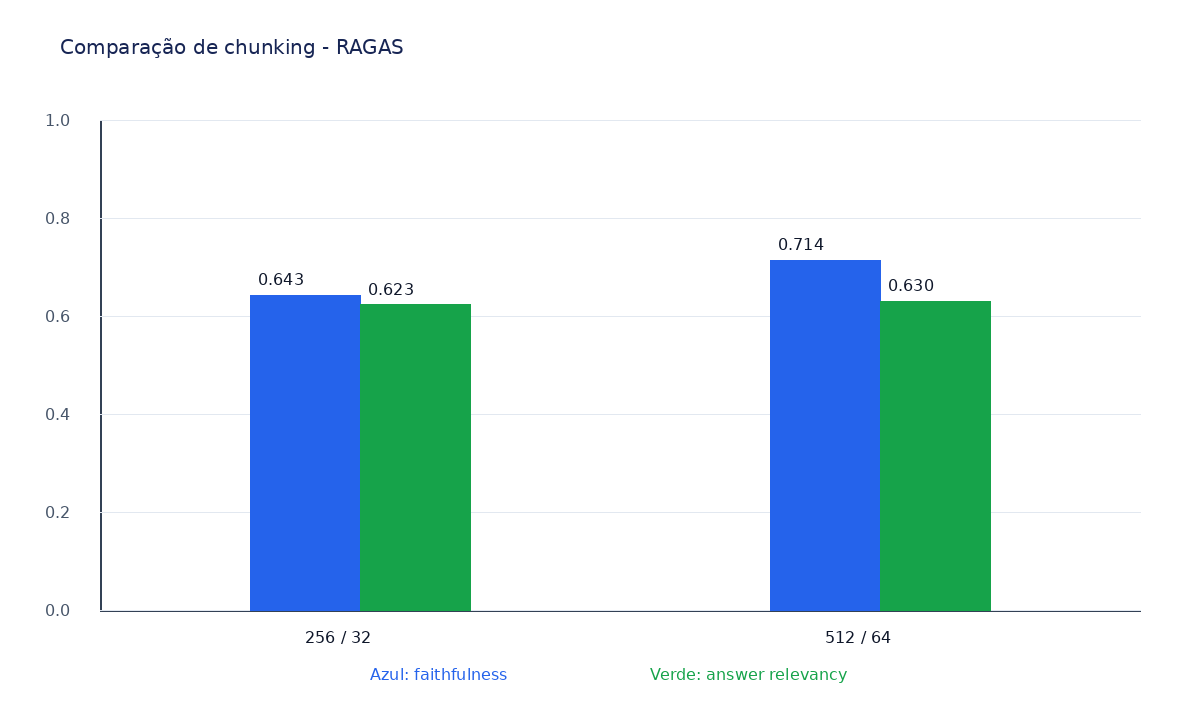

Configuração vencedora validada: 512/64, com faithfulness médio acima da meta 0,7.


In [6]:
evaluation_dir = PROJECT_ROOT / 'artifacts/evaluation'
per_question = pd.read_csv(evaluation_dir / 'resultados_por_pergunta.csv')
summary = pd.read_csv(evaluation_dir / 'resumo_por_configuracao.csv')
display(per_question)
display(summary)
display(Image(filename=evaluation_dir / 'comparacao_chunking.png'))
winner = summary.sort_values(['faithfulness_mean', 'answer_relevancy_mean'], ascending=False).iloc[0]
assert int(winner['chunk_size']) == 512 and int(winner['chunk_overlap']) == 64
assert float(winner['faithfulness_mean']) >= 0.7
print('Configuração vencedora validada: 512/64, com faithfulness médio acima da meta 0,7.')

## 5. Diferenciais

O projeto implementa filtro por metadata, reranking por cross-encoder e interface Gradio. O reranking permanece desativado por padrão porque melhorou o recall de fontes, mas acrescentou latência e não melhorou toda resposta gerada.

In [7]:
phase5_dir = PROJECT_ROOT / 'artifacts/phase5'
comparison = pd.read_csv(phase5_dir / 'comparacao_recuperacao.csv')
display(comparison)
display(Markdown((phase5_dir / 'relatorio.md').read_text(encoding='utf-8')))

,id,question,expected_documents,filter_category,baseline_recall,filtered_recall,reranked_recall,baseline_latency_seconds,filtered_latency_seconds,reranked_latency_seconds,baseline_ids,filtered_ids,reranked_ids
0,Q01,Qual é o prazo mínimo de inscrição indicado pa...,DOC-04,selecao_por_competencias,1.0,1.0,1.0,0.2121,0.2286,3.3314,"DOC-04-C0058,DOC-04-C0059,DOC-04-C0060,DOC-04-...","DOC-04-C0058,DOC-04-C0059,DOC-04-C0060,DOC-04-...","DOC-04-C0058,DOC-04-C0059,DOC-04-C0060,DOC-04-..."
1,Q02,Em quais situações um processo seletivo pode s...,DOC-04,selecao_por_competencias,1.0,1.0,1.0,0.2339,0.2434,3.5154,"DOC-04-C0050,DOC-04-C0051,DOC-04-C0052,DOC-04-...","DOC-04-C0050,DOC-04-C0051,DOC-04-C0052,DOC-04-...","DOC-04-C0050,DOC-04-C0051,DOC-04-C0052,DOC-04-..."
2,Q03,Quais informações devem constar no formulário ...,DOC-01,recrutamento_e_selecao,1.0,1.0,1.0,0.2004,0.2668,2.2081,"DOC-01-C0035,DOC-01-C0036,DOC-01-C0037,DOC-01-...","DOC-01-C0035,DOC-01-C0036,DOC-01-C0037,DOC-01-...","DOC-01-C0039,DOC-01-C0040,DOC-01-C0041,DOC-01-..."
3,Q04,Quais práticas ajudam a estruturar uma entrevi...,DOC-04,selecao_por_competencias,1.0,1.0,1.0,0.2923,0.2342,9.1508,"DOC-04-C0101,DOC-04-C0102,DOC-04-C0103,DOC-02-...","DOC-04-C0101,DOC-04-C0102,DOC-04-C0103,DOC-04-...","DOC-04-C0101,DOC-04-C0102,DOC-04-C0103,DOC-04-..."
4,Q05,Quais princípios devem orientar um processo de...,DOC-03,recrutamento_justo,1.0,1.0,1.0,0.2040,0.1905,3.3978,"DOC-01-C0244,DOC-01-C0245,DOC-01-C0246,DOC-03-...","DOC-03-C0067,DOC-03-C0068,DOC-03-C0069,DOC-03-...","DOC-03-C0001,DOC-03-C0002,DOC-03-C0003,DOC-03-..."
5,Q06,Quais cuidados de privacidade devem ser adotad...,DOC-02,privacidade,1.0,1.0,1.0,0.2327,0.2996,4.2288,"DOC-02-C0291,DOC-02-C0292,DOC-02-C0293,DOC-02-...","DOC-02-C0291,DOC-02-C0292,DOC-02-C0293,DOC-02-...","DOC-04-C0162,DOC-04-C0163,DOC-04-C0164,DOC-02-..."
6,Q07,Por que critérios vagos de 'perfil cultural' p...,"DOC-02,DOC-05",NaN,0.5,NaN,1.0,0.2844,NaN,3.9322,"DOC-02-C0321,DOC-02-C0322,DOC-02-C0323,DOC-02-...",NaN,"DOC-02-C0542,DOC-02-C0543,DOC-02-C0544,DOC-05-..."


# Fase 5 — comparação dos diferenciais

Execução real em `2026-10-08T20:17:42.721859-03:00` sobre 7 perguntas respondíveis. O índice e o cross-encoder foram aquecidos antes da medição.

| Estratégia | Perguntas | Recall médio de fontes | Latência média |
|---|---:|---:|---:|
| Busca vetorial | 7 | 0.929 | 0.237 s |
| Cross-encoder | 7 | 1.000 | 4.252 s |
| Filtro por metadata | 6 | 1.000 | ver CSV |

O filtro foi avaliado apenas quando todos os documentos esperados tinham a mesma categoria. O cross-encoder usa 10 candidatos, seleciona 5 hits e reanexa seus vizinhos disponíveis. O CSV preserva IDs, recalls e latências por pergunta. Recall não mede faithfulness da resposta; ele compara somente a etapa de recuperação. Em um smoke test de geração sobre coleta e guarda de currículos, a busca vetorial respondeu com três chunks válidos, enquanto o contexto reordenado levou o gerador a declarar evidência insuficiente. Por isso, o reranking fica experimental e desativado por padrão na interface.


## 6. Reprodução e entrega

1. Copie `.env.example` para `.env` e configure `OLLAMA_API_KEY`.
2. Instale `requirements.txt` e mantenha o Ollama local com `nomic-embed-text` disponível.
3. Execute `python -m app.ingestion`, `python -m app.phase3`, `python -m app.evaluation` e, opcionalmente, `python -m app.phase5`.
4. Inicie a interface com `python -m app.main`.
5. Para adicionar documentos, atualize `data/manifest.json` com fonte, categoria, arquivo, tamanho e SHA-256 e reconstrua os índices.

Limitações: o embedding cloud obrigatório não estava liberado para a conta durante a execução e foi usado localmente; RAGAS usa LLM como juiz e pode variar; toda decisão sobre pessoas exige revisão humana. Consulte o README para metodologia, privacidade e instruções completas.

In [8]:
required = [PROJECT_ROOT / 'README.md',
            PROJECT_ROOT / 'artifacts/evaluation/configuracao_execucao.json',
            PROJECT_ROOT / 'artifacts/evaluation/relatorio.md',
            PROJECT_ROOT / 'artifacts/rag/fase3.json']
missing = [str(path.relative_to(PROJECT_ROOT)) for path in required if not path.is_file()]
assert not missing, f'Artefatos ausentes: {missing}'
print('Notebook concluído: base, pipeline, citações, métricas e diferenciais validados sem erros.')

Notebook concluído: base, pipeline, citações, métricas e diferenciais validados sem erros.
